<a href="https://colab.research.google.com/github/elariekerboull/master_uppsala/blob/main/Machine%20Learning/Exercise_9_autoencoders_lab_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autoencoders Lab
#### visualizing HapMap phase 3 populations

---

In this lab, we will use chip genotyping data from the HapMap project (phase 3). These data come from a number of humans belonging to different ethnic groups/populations. The groups are genetically distinct but, in some cases, closely related and thus somewhat difficult to distinguish. We will first try to visualize population structure using classical dimensionality reduction techniques (PCA, MDS). Next, we will build autoencoder and see if it does any different in separating different populations. Throughout the lab, we will use keras interface to TensorFlow.

---

### Background
The purpose of this lab is to evaluate the possibility of using autoencoder as a replacement/complement to more “classical” linear dimensionality reduction methods such as PCA or MDS. These are commonly used for, e.g. visualizing population structure in genetics. One of the main motivations is that when inferring genomic kinship from a large number of markers M (large enough to capture population structure at fine level), one necessarily introduces correlations between variables, here, genetic markers. This is predominantly due to the linkage disequilibrium, but also due to the large M that, even by pure chance, introduces correlated variables to the data. This correlation structure introduces non-linearity that, in turn, makes the data not very well suitable for PCA/MDS since both approaches rely on computing kinship matrix determinants that, for a lot of highly correlated variables, become 0 and prevent us from computing exact solutions (division by zero is undefined).

### Data

Here, the working hypotheses is that by choosing non-linear activation functions, e.g. ReLU, one can circumvent this problem and use autoencoder approach to reduce the dimensionality by embedding kinship data in a low dimensional latent representation space that, in turn, can easily be visualized. The idea emerged during the EMBL conference Reconstructing the Human Past, Heidelberg 🍺, April 2019, in a number of discussions with Nikolay Oskolkov 👨‍🔬 and other conference participants: 🐿, 🦓 and 🐉.

Data comes from the HapMap phase 3 project. Here, for computational feasibility, we will be using smaller dataset. I have pre-selected 5,000 autosomal markers with call rate of 100%. We will not be dealing with missing data here although autoencoders, in contrast to PCA and MDS, can.

HapMap 3 populations:

* ASW – African 🌍 ancestry in Southwest USA 🇺🇸
* CEU – Utah residents with Northern and Western European 🌍 ancestry from the CEPH collection
* CHB – Han Chinese in Beijing, China 🇨🇳
* CHD – Chinese 🇨🇳 in Metropolitan Denver, Colorado ⛰
* GIH – Gujarati Indians 🇮🇳 in Houston, Texas
* JPT – Japanese in Tokyo, Japan 🇯🇵
* LWK – Luhya in Webuye, Kenya 🇰🇪
* MEX – Mexican 🇲🇽 ancestry in Los Angeles, California 🐻
* MKK – Maasai in Kinyawa, Kenya 🇰🇪
* TSI – Toscans 🛵 in Italy 🇮🇹
* YRI – Yoruba in Ibadan, Nigeria 🇳🇬

### Stage 0 &mdash; getting the data

First, we will download the data from the linked Dropbox account.



In [ ]:
#@title Load raw data. Double click to see the code. { display-mode: "form" }

!wget https://www.dropbox.com/s/g7862q1l4ls9z3x/autosomal_5k_matrix.csv
!wget https://www.dropbox.com/s/3lv0062dw20qdqg/autosomal_5k_phenos.csv
!wget https://www.dropbox.com/s/6nzrusxkm536a5j/autosomal_5k_kinship.csv

--2024-11-05 11:51:26--  https://www.dropbox.com/s/g7862q1l4ls9z3x/autosomal_5k_matrix.csv
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/a6mehjrpky5u3kwqle74i/autosomal_5k_matrix.csv?rlkey=1iufpj9nhjrm9q3f9ah0msq1d [following]
--2024-11-05 11:51:26--  https://www.dropbox.com/scl/fi/a6mehjrpky5u3kwqle74i/autosomal_5k_matrix.csv?rlkey=1iufpj9nhjrm9q3f9ah0msq1d
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc061ad5c603c4f62518ec4dd742.dl.dropboxusercontent.com/cd/0/inline/Cdz_XvogmWygDMR-v_zxgoI4hqWZSRaI9uijsOjYxmksArv-xh7PIAlVwXwohgtbGMXnDfuTmsiQ8PV0KjMo6h7xL1BOF58fqpIekHwWu0R-LjY1pTy0upmlK-xO3vucljI/file# [following]
--2024-11-05 11:51:27--  https://uc061ad5c603c4f62518ec4dd742.dl.dropboxusercontent.com/c

Now, we will load the data and make sure they look as expected. Note, the genotypes per individual (row) are encoded as the count of minor alleles and thus can take values `gt = {0, 1, 2}`.

**Q1** Check names of the loci. Can you tell which chromosome a locus is on based on these names?

**ANS1** Not directly, one could use online resources such as BioMart or dbSNP.

Now, look at the phenotypic data.

**Q2** How many individuals do we have in the dataset?  
**ANS2*** 1184 individuals.

**Q3** How many individuals per population do we have? Do they have the same number of males and females?  

Population    Individuals     Males     Females    Families  
   ASW             83           38         45        40  
   CEU            165           80         85        36   
   CHB             84           42         42        84   
   CHD             85           41         44        85   
   GIH             88           45         43        88  
   JPT             86           44         42        86  
   LWK             90           45         45        90  
   MEX             77           34         43        27  
   MKK            171           86         85        88  
   TSI             88           44         44        88  
   YRI            167           90         77        58  
   Tot.          1184          589        595       770  

**Q4** How many full- and half-siblings do we have in the dataset?
0 full-sibs
0 half-sibs

**Q5** How many families do we have?
770

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt

geno_data = pd.read_csv("autosomal_5k_matrix.csv", header=0, index_col=0)
pheno = pd.read_csv("autosomal_5k_phenos.csv", header=0, index_col=0)

print(geno_data)
print(pheno)


         rs416967  rs17013842  rs13052452  rs11049986  rs10994341  rs1504289  \
NA19919         2           1           0           1           1          0   
NA19916         1           0           0           1           1          0   
NA19835         0           0           1           1           0          1   
NA20282         1           1           0           1           0          0   
NA19703         0           0           0           0           1          1   
...           ...         ...         ...         ...         ...        ...   
NA19119         1           0           1           0           1          1   
NA18860         1           0           0           1           1          0   
NA19207         2           0           0           0           1          0   
NA19103         1           0           1           0           0          0   
NA19099         0           0           1           1           0          1   

         rs882529  rs3885937  rs537330 

In [ ]:
pop_dict = {'ASW':'African ancestry in SW USA',
            'CEU':'Utah residents with N and W European ancestry',
            'CHB':'Han Chinese in Beijing China',
            'CHD':'Chinese in Metropolitan Denver Colorado',
            'GIH':'Gujarati Indians in Houston Texas',
            'JPT':'Japanese in Tokyo Japan',
            'LWK':'Luhya in Webuye Kenya',
            'MEX':'Mexican ancestry in Los Angeles California',
            'MKK':'Maasai in Kinyawa Kenya',
            'TSI':'Toscans in Italy',
            'YRI':'Yoruba in Ibadan Nigeria'}
pheno2 = pheno.replace({"population": pop_dict})
pheno2

,id,sex,FID,dad,mom,pheno,population
NA19919,NA19919,1,2427,NA19908,NA19909,0,African ancestry in SW USA
NA19916,NA19916,1,2431,0,0,0,African ancestry in SW USA
NA19835,NA19835,0,2424,0,0,0,African ancestry in SW USA
NA20282,NA20282,0,2469,0,0,0,African ancestry in SW USA
NA19703,NA19703,1,2368,0,0,0,African ancestry in SW USA
...,...,...,...,...,...,...,...
NA19119,NA19119,1,Y060,0,0,0,Yoruba in Ibadan Nigeria
NA18860,NA18860,1,Y012,NA18859,NA18858,0,Yoruba in Ibadan Nigeria
NA19207,NA19207,1,Y051,0,0,0,Yoruba in Ibadan Nigeria
NA19103,NA19103,1,Y042,NA19101,NA19102,0,Yoruba in Ibadan Nigeria


In [ ]:
# Scaling
# We need to scale our counts data so that it is bound between 0 and 1.
# Now, the AA homozygotes will be coded as 0, heterozygotes as 0.5 and aa homozygotes as 1.

geno_data = geno_data / 2
geno_data

,rs416967,rs17013842,rs13052452,rs11049986,rs10994341,rs1504289,rs882529,rs3885937,rs537330,rs9372090,...,rs1558766,rs7818288,rs1051685,rs11223492,rs789492,rs6557516,rs7313246,rs317892,rs11937009,rs2806497
NA19919,1.0,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.5,0.5,...,0.0,0.5,0.0,0.0,0.5,0.0,0.5,0.5,0.5,0.0
NA19916,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.0
NA19835,0.0,0.0,0.5,0.5,0.0,0.5,0.0,1.0,1.0,0.5,...,0.0,0.5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
NA20282,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0
NA19703,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,1.0,...,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19119,0.5,0.0,0.5,0.0,0.5,0.5,0.5,0.5,0.5,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0
NA18860,0.5,0.0,0.0,0.5,0.5,0.0,0.0,0.5,1.0,0.5,...,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5
NA19207,1.0,0.0,0.0,0.0,0.5,0.0,0.5,0.5,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.5,0.0
NA19103,0.5,0.0,0.5,0.0,0.0,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,1.0,0.0


In [ ]:
# Optional noise injection (missing values)
import random
noisy_data = (geno_data + 0.4) / 4
noisy_data = noisy_data.applymap(lambda x: 0 if random.randint(0, 1000) <= 50 else x)
# geno_data = noisy_data
print(noisy_data)

<ipython-input-5-7f309bfdabc5>:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  noisy_data = noisy_data.applymap(lambda x: 0 if random.randint(0, 1000) <= 50 else x)


         rs416967  rs17013842  rs13052452  rs11049986  rs10994341  rs1504289  \
NA19919     0.350       0.225       0.100       0.225       0.225      0.100   
NA19916     0.225       0.100       0.100       0.225       0.225      0.100   
NA19835     0.100       0.000       0.225       0.225       0.100      0.225   
NA20282     0.225       0.225       0.100       0.225       0.100      0.100   
NA19703     0.100       0.100       0.100       0.100       0.225      0.225   
...           ...         ...         ...         ...         ...        ...   
NA19119     0.225       0.100       0.225       0.100       0.225      0.225   
NA18860     0.225       0.100       0.100       0.225       0.225      0.100   
NA19207     0.350       0.100       0.100       0.100       0.225      0.000   
NA19103     0.225       0.100       0.225       0.100       0.100      0.100   
NA19099     0.100       0.000       0.225       0.225       0.100      0.225   

         rs882529  rs3885937  rs537330 

In [ ]:
# Randomly split into the training and the validation set

train = geno_data.sample(frac = 0.8, random_state = 42)
test = geno_data.drop(train.index)
train.reset_index()
test.reset_index()

# Print some info about the resulting split
print("Number of individuals:", geno_data.shape[0])
print("\t - training set:", train.shape)
print("\t - test set:", test.shape)

Number of individuals: 1184
	 - training set: (947, 5000)
	 - test set: (237, 5000)


In [ ]:
train_tensor = train.to_numpy()

# Hyperparameters
hp_loss_fn = 'mse'
hp_act_fn = 'relu'
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

def Encoder(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.05, name='layer3')(layer2)
  layer3n = layers.BatchNormalization(name='layer3n')(layer3)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn, name='layer4')(layer3n)
  layer4n = layers.BatchNormalization(name='layer4n')(layer4)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 25, activation = hp_act_fn, name='layer6')(layer5)
  layer6n = layers.BatchNormalization(name='layer6n')(layer6)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

def Decoder(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 25, activation = hp_act_fn)(bottleneck)
  layer7n = layers.BatchNormalization(name='layer7n')(layer7)
  layer8 = layers.Dropout(rate = 0.025)(layer7n)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn)(layer8)
  layer9n = layers.BatchNormalization(name='layer9n')(layer9)
  layer10 = layers.Dropout(rate = 0.05)(layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn)(layer10)
  layer11n = layers.BatchNormalization(name='layer11n')(layer11)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid')(layer11)
  return(layer12)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)
autoencoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 5000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer1 (Dense)                       │ (None, 1500)                │       7,501,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer2 (BatchNormalization)          │ (None, 1500)                │           6,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer3 (Dropout)                     │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer3n (BatchNormalization)         │ (None, 1500)                │           6,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer4 (Dense)                       │ (None, 250)                 │         375,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer5 (Dropout)                     │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer6 (Dense)                       │ (None, 25)                  │           6,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_bottleneck (Dense)             │ (None, 2)                   │              52 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 25)                  │              75 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer7n (BatchNormalization)         │ (None, 25)                  │             100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 250)                 │           6,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1500)                │         376,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5000)                │       7,505,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,783,252 (60.21 MB)

 Trainable params: 15,777,202 (60.19 MB)

 Non-trainable params: 6,050 (23.63 KB)

In [ ]:
# Set hyperparameters
hp_epochs = 100
hp_batch_size = 256
hp_val_split = 0.2

autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 761ms/step - loss: 0.1812 - mae: 0.3696 - mape: 336652576.0000 - mse: 0.1812 - val_loss: 0.1817 - val_mae: 0.3673 - val_mape: 337547424.0000 - val_mse: 0.1817
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 594ms/step - loss: 0.1467 - mae: 0.3392 - mape: 293984672.0000 - mse: 0.1467 - val_loss: 0.1566 - val_mae: 0.3480 - val_mape: 308526848.0000 - val_mse: 0.1566
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 591ms/step - loss: 0.0906 - mae: 0.2685 - mape: 186247680.0000 - mse: 0.0906 - val_loss: 0.0913 - val_mae: 0.2723 - val_mape: 196685536.0000 - val_mse: 0.0913
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 903ms/step - loss: 0.0735 - mae: 0.1965 - mape: 77349480.0000 - mse: 0.0735 - val_loss: 0.0742 - val_mae: 0.2090 - val_mape: 110831648.0000 - val_mse: 0.0742
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - loss: 0.0749 - mae: 0.1718 - mape: 52724136.0000 - mse: 0.0749 - val_loss: 0.0737 - val_mae: 0.1885 - val_mape: 92013888.0000 - val_mse: 0.0737
Epoch 6/

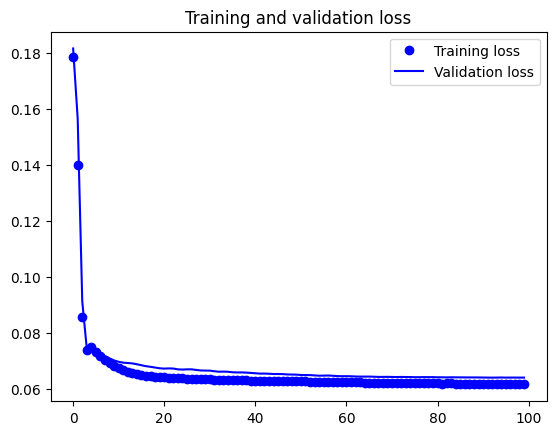

In [ ]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
autoencoder_model.save_weights('autoencoder_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('autoencoder_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
[[ -6.034377  -20.066803 ]
 [ -5.2217617 -20.08937  ]
 [ -4.215112  -19.421452 ]
 ...
 [ -7.98377   -21.261147 ]
 [ -5.668769  -27.585712 ]
 [ -8.305639  -23.738533 ]]


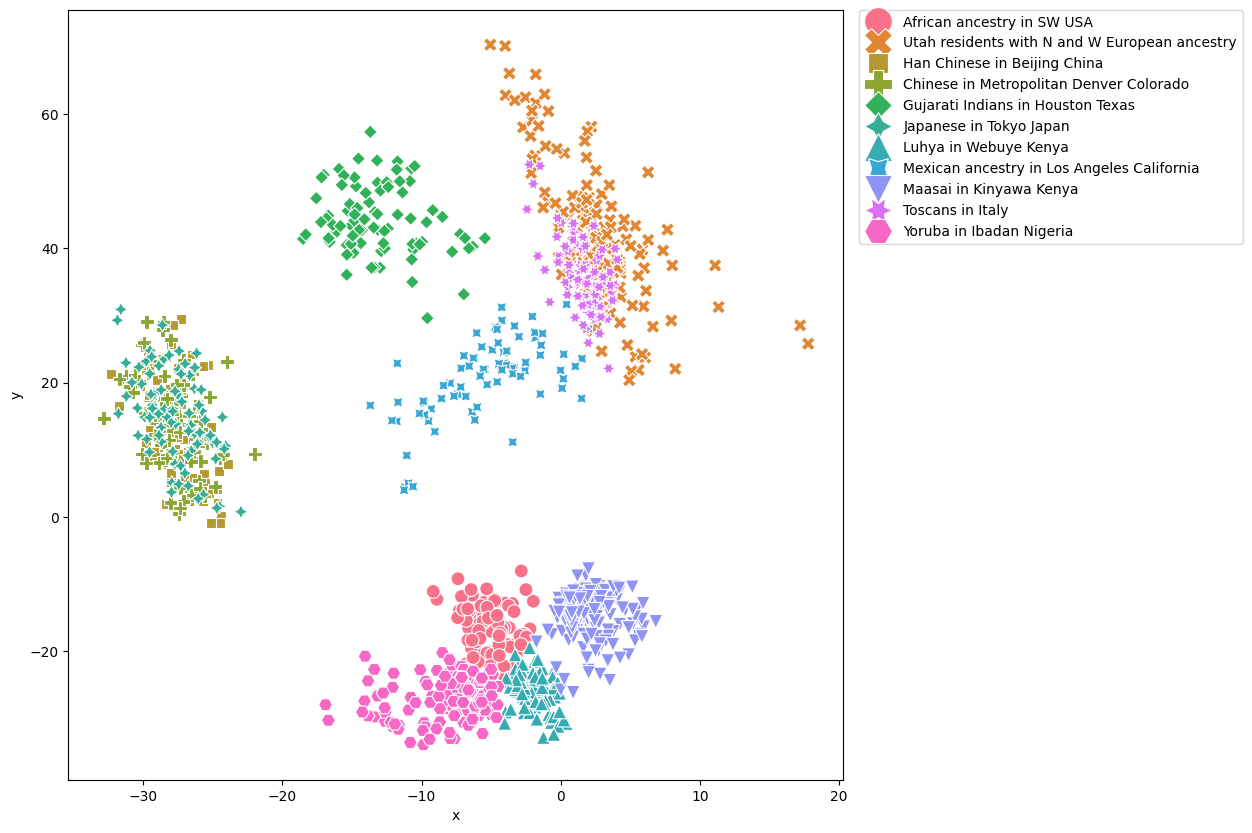

In [ ]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

In [ ]:
kinship = pd.read_csv("autosomal_5k_kinship.csv", header=0, index_col=0)


In [ ]:
from sklearn.manifold import MDS
embedding = MDS(n_components=2)
mds_embedding = embedding.fit_transform(kinship)


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_mds.py:629: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(


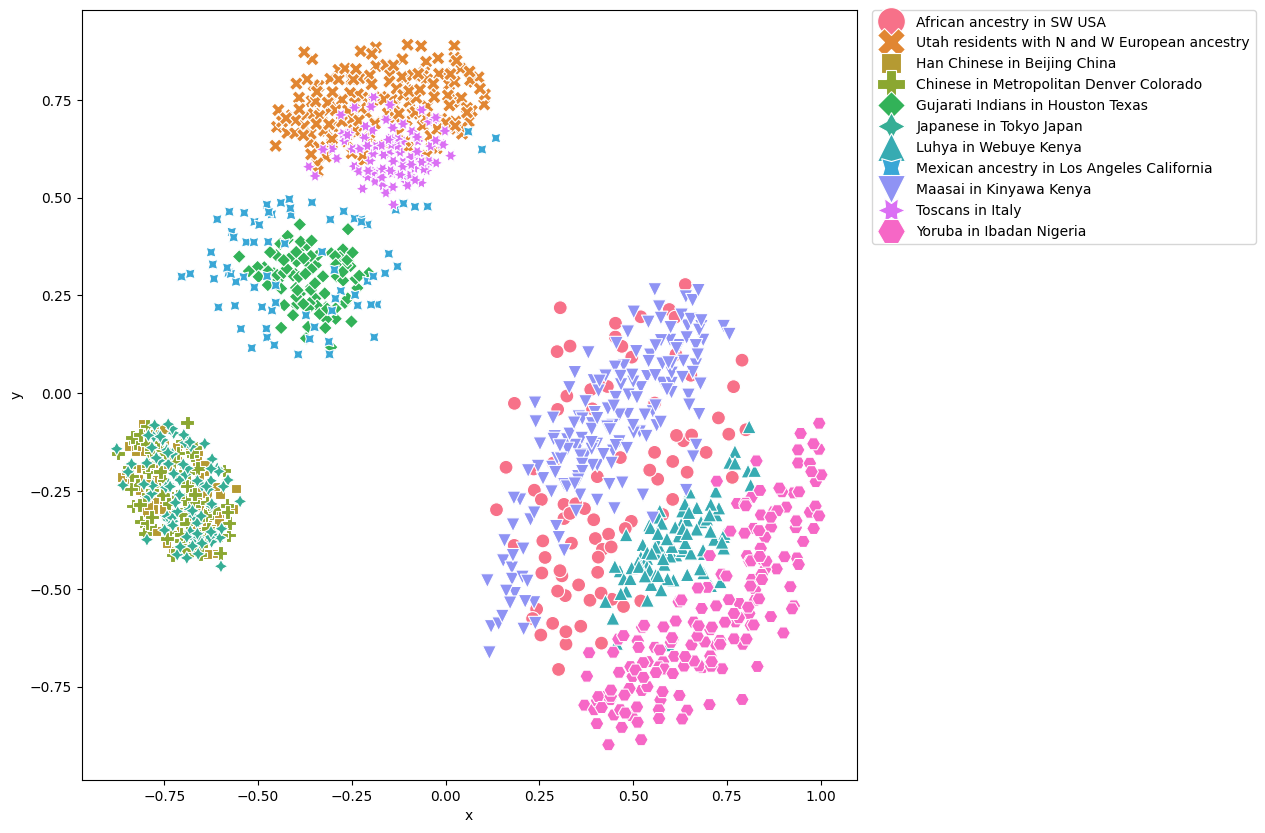

In [ ]:
x = mds_embedding[:,0]
y = mds_embedding[:,1]
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

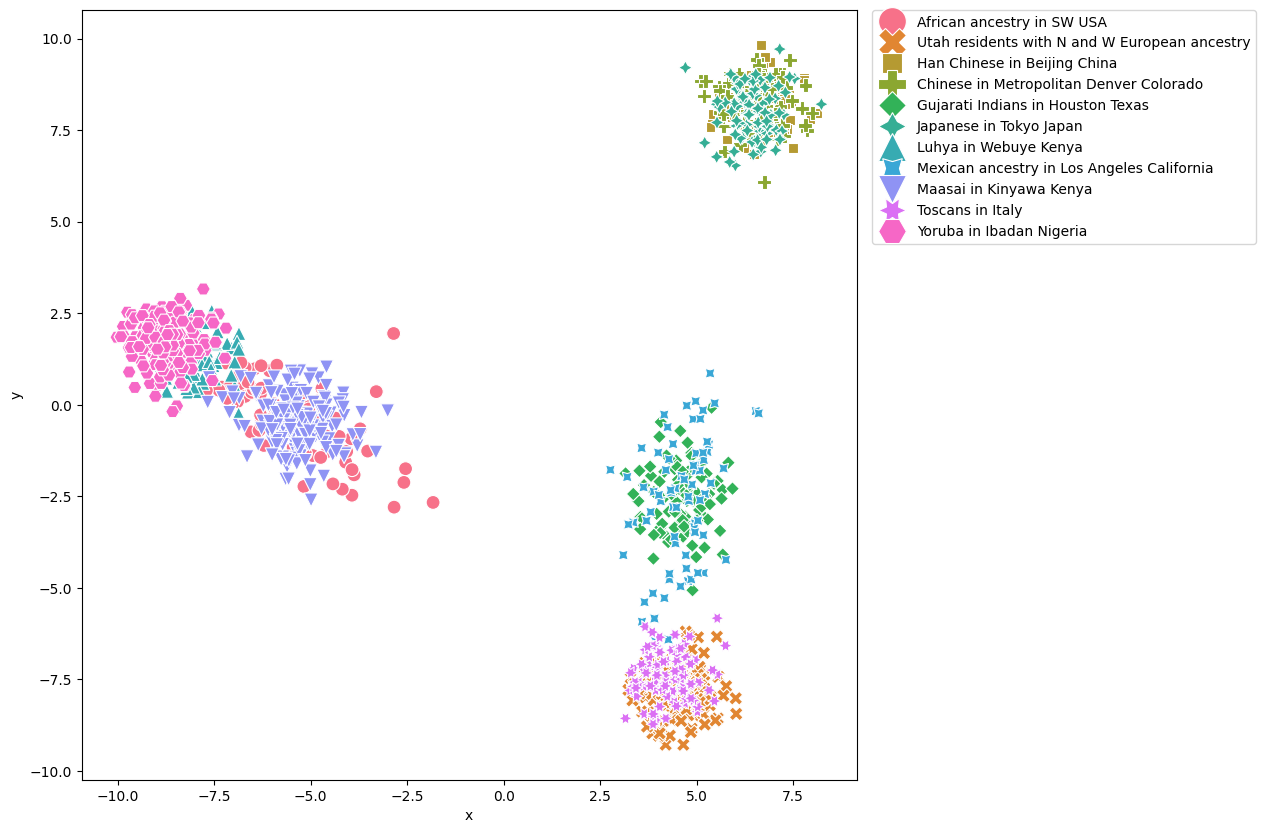

In [ ]:
from sklearn.decomposition import PCA
embedding = PCA(n_components=2)
pca_embedding = embedding.fit_transform(geno_data * 2)
x = pca_embedding[:,0]
y = pca_embedding[:,1]
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()